/home/myt8099/.conda/envs/bert/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


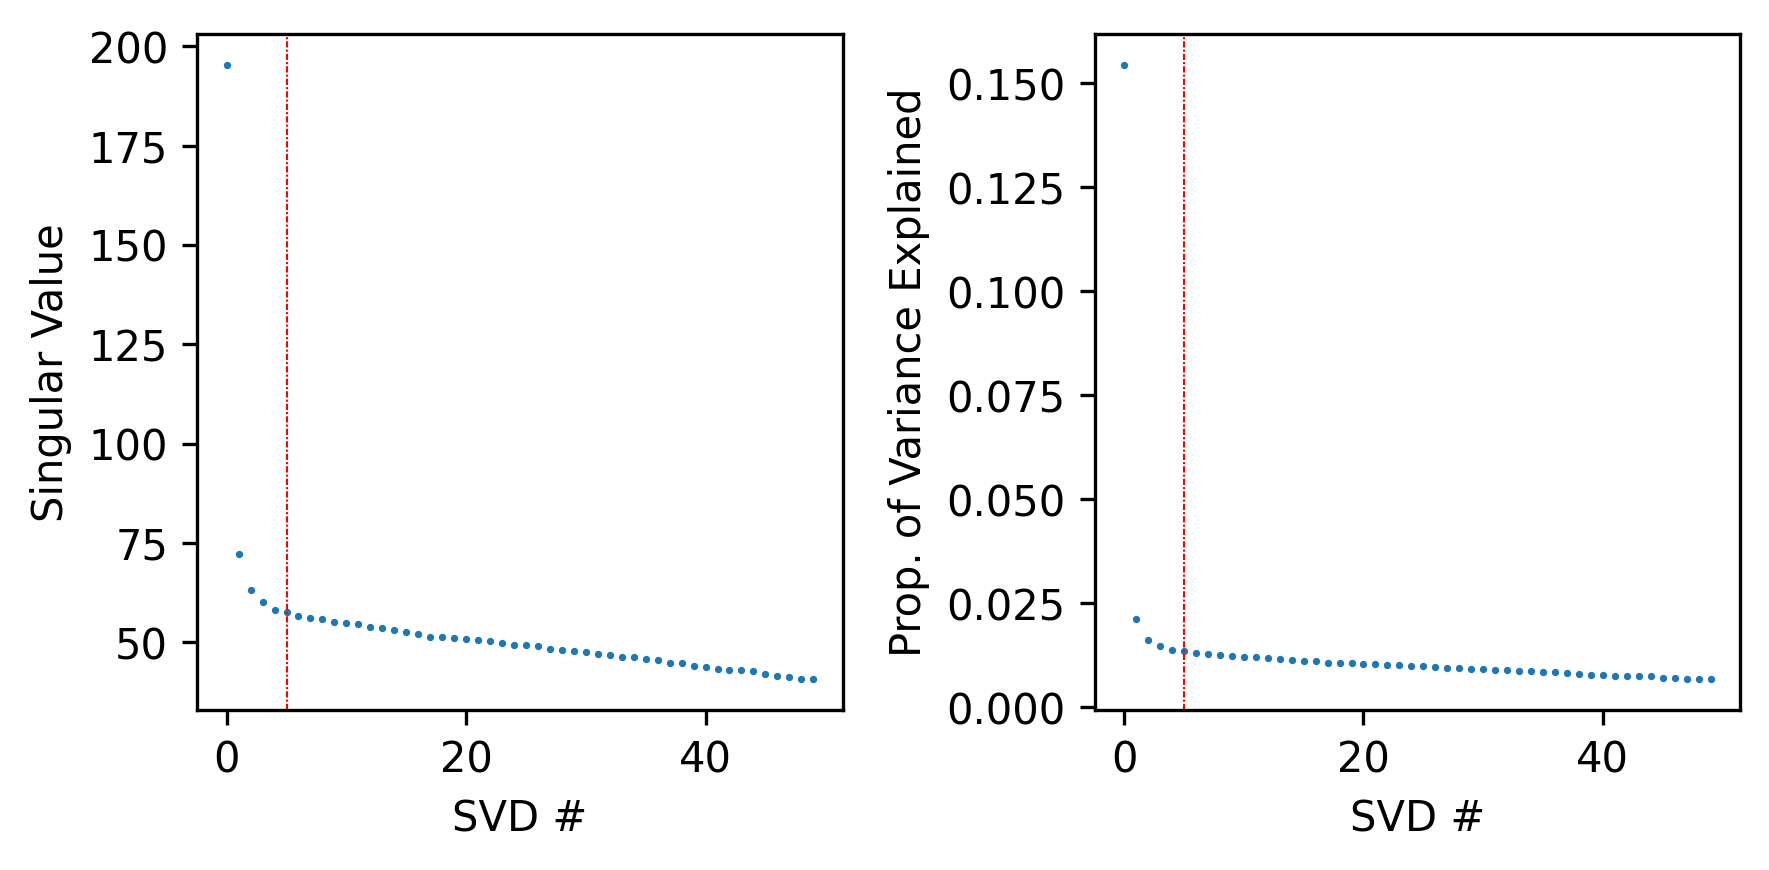

In [2]:
import os
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.feature_selection import SelectKBest, f_classif

sys.path.append("../../Utils")
from loaders import HNSCCFeatureHandler

METADATA_PATH = "../../Supplementary_Tables/ST1/RAW_HNSCC_METADATA_NEW_v10.csv"
VALID_IDS_PATH = "../../Utils/Lists/cv_ids.txt"
HOLD_IDS_PATH = '../../Utils/Lists/holdout_ids.txt'

hc_data = HNSCCFeatureHandler(METADATA_PATH, VALID_IDS_PATH, HOLD_IDS_PATH)
_ = hc_data.load_feature_to_dataframe("../../Data/*.hg38.frag.interval_mds.tsv", 0, 4)
z = hc_data.normalize_zscore()
_ = hc_data.merge_feature_metadata()
z = hc_data.batch_correct()

final_patient_df_combined = hc_data.get_raw_features()
final_patient_df_combined_metadata = hc_data.get_metadata_col("Treatment Response")
final_patient_df_combined = pd.concat([final_patient_df_combined, final_patient_df_combined_metadata], axis=1)

X_combined = final_patient_df_combined.iloc[:, :-1]
y_combined = final_patient_df_combined.iloc[:, -1]

y_combined = y_combined.astype(str)

X_combined['Treatment Response'] = y_combined
U, S, Vt = np.linalg.svd(X_combined.iloc[:, :-1], full_matrices=False)
prop_var_explained = (S**2) / np.sum(S**2)

plt.figure(figsize=(6, 3), dpi=300)

plt.subplot(1, 2, 1)
plt.plot(S[:50], 'o', markersize=0.75)
plt.xlabel("SVD #")
plt.ylabel("Singular Value")
plt.axvline(x=5, color='red', linestyle=(0, (3, 1, 1, 1)), linewidth=0.5)


plt.subplot(1, 2, 2)
plt.plot(prop_var_explained[:50], 'o', markersize=0.75)
plt.xlabel("SVD #")
plt.ylabel("Prop. of Variance Explained")
plt.axvline(x=5, color='red', linestyle=(0, (3, 1, 1, 1)), linewidth=0.5)

plt.tight_layout()
plt.savefig("F2B.rMDS.SVD.v1.pdf")
plt.show()

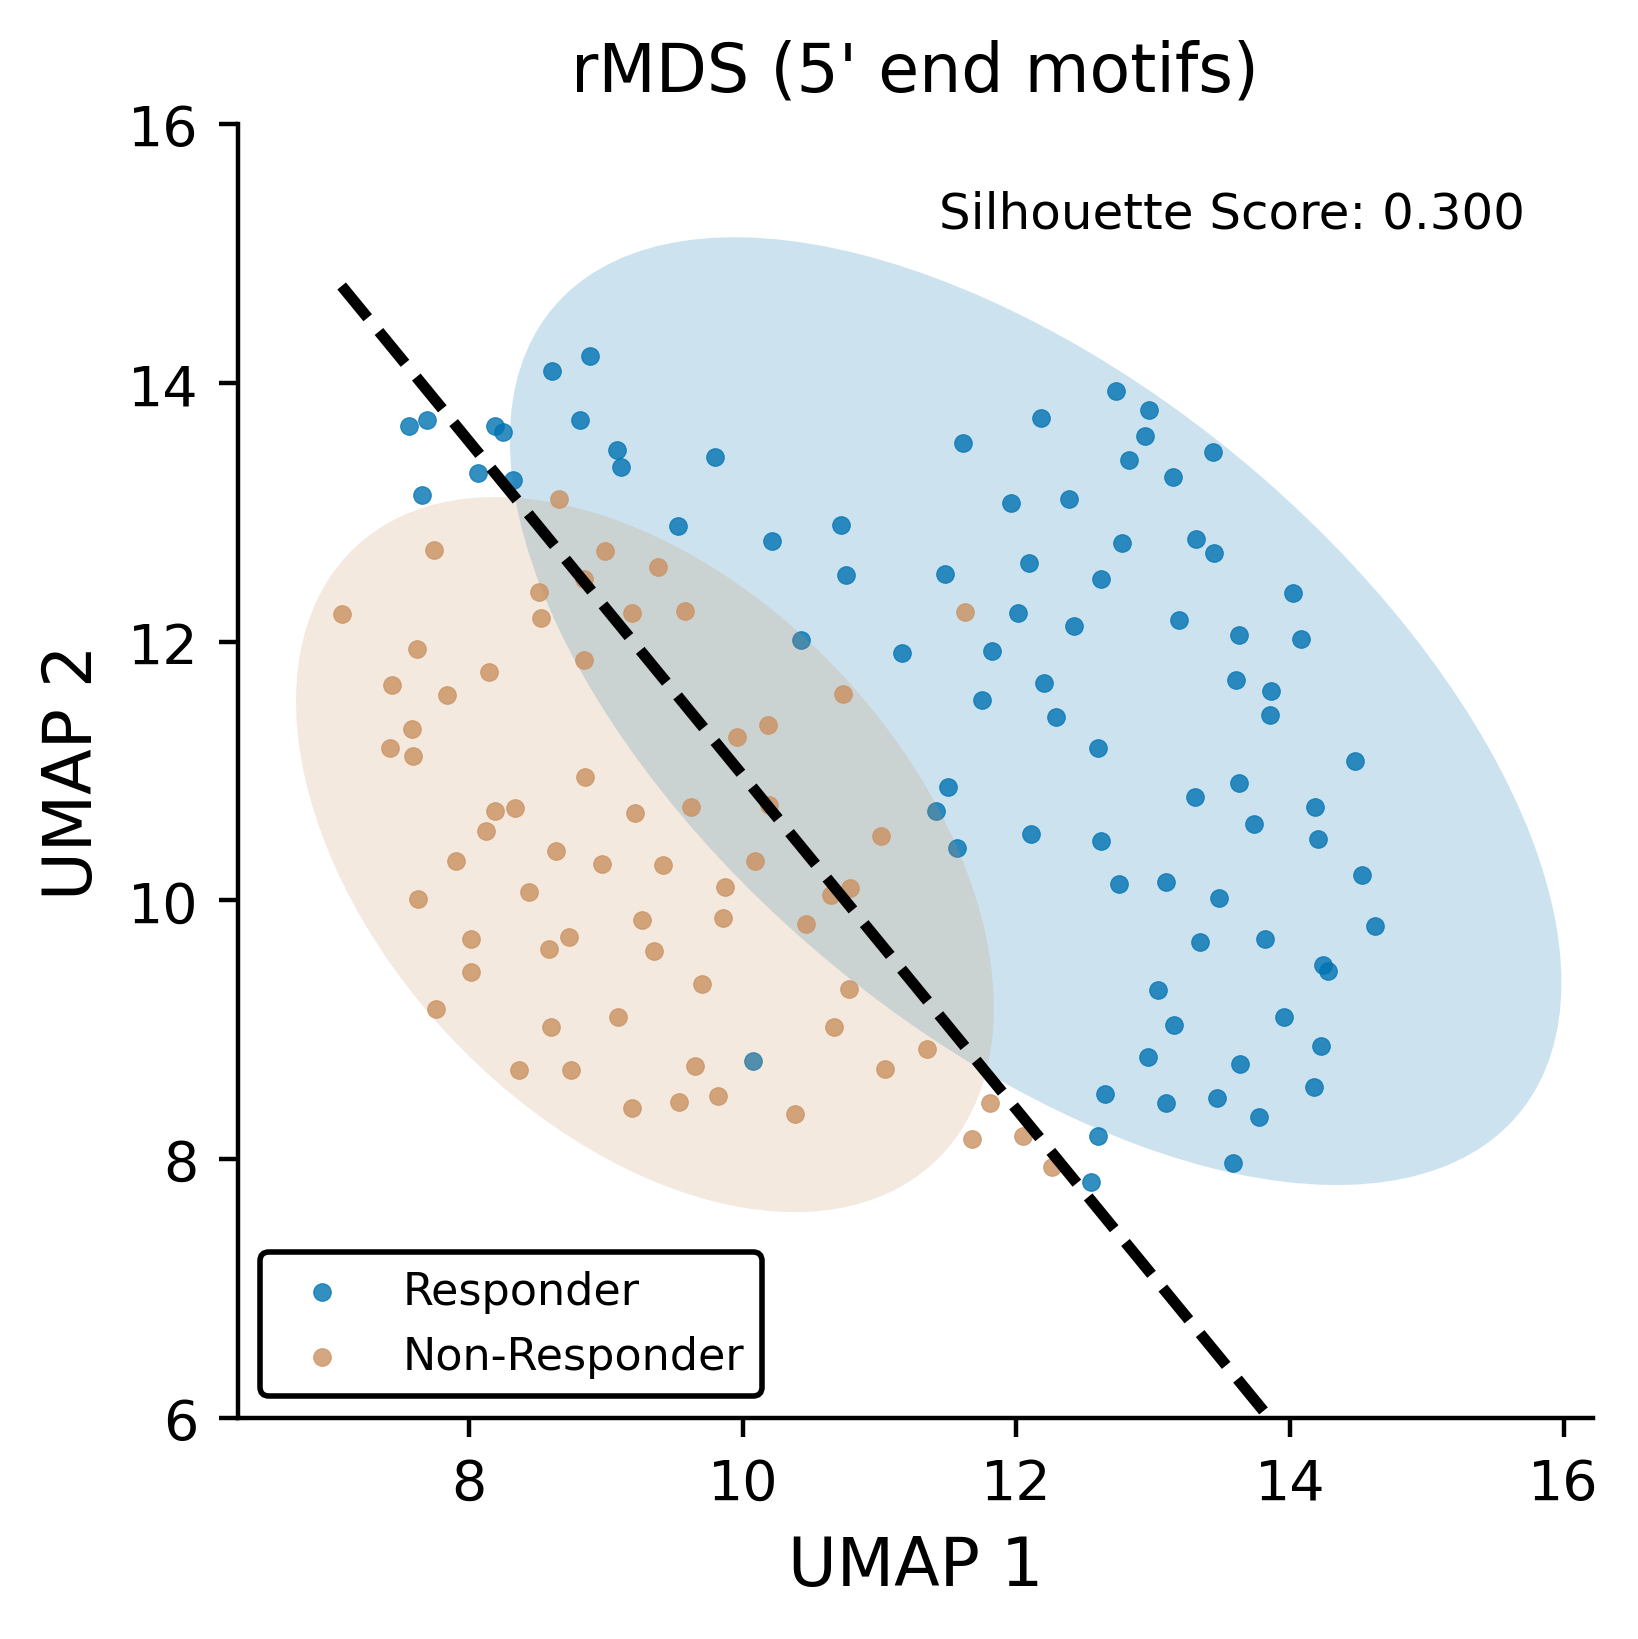

In [12]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from shapely.geometry import Point
from shapely.affinity import rotate, scale, translate
from sklearn.metrics import silhouette_score
import umap

umap_model = umap.UMAP(n_components=2, n_neighbors=50, min_dist=0.5, metric='cosine', random_state=42)
umap_result = umap_model.fit_transform(U[:, :6])

umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'], index=X_combined.index)
umap_df['Treatment Response'] = X_combined['Treatment Response']

score = silhouette_score(umap_df[['UMAP1', 'UMAP2']], umap_df['Treatment Response'])

unique_treatments = umap_df['Treatment Response'].unique()
colors = sns.color_palette('colorblind', 10)
selected_colors = [colors[5], colors[0]]
color_map = {treatment: selected_colors[i % len(selected_colors)] for i, treatment in enumerate(unique_treatments)}

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if x.size <= 1: return
    cov = np.cov(x, y)
    if np.any(np.isnan(cov)) or np.linalg.det(cov) == 0: return
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ellipse = Ellipse((np.mean(x), np.mean(y)), width=width, height=height,
                      angle=angle, facecolor=facecolor, **kwargs)
    ax.add_patch(ellipse)

def get_ellipse_polygon(x, y, width, height, angle_deg, num_points=200):
    circ = Point(0, 0).buffer(1, resolution=num_points)
    ell = scale(circ, width / 2.0, height / 2.0)
    ell = rotate(ell, angle_deg, origin=(0, 0))
    ell = translate(ell, x, y)
    return ell

fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=400)

ellipses = []
for treatment, color in reversed(list(color_map.items())):
    subset = umap_df[umap_df['Treatment Response'] == treatment]
    x, y = subset['UMAP1'].values, subset['UMAP2'].values
    ax.scatter(x, y, color=color, label=treatment, s=10, linewidth=0.2, alpha=0.8)
    confidence_ellipse(x, y, ax, n_std=2, facecolor=color, alpha=0.2, edgecolor='none')

    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    width, height = 2 * 2 * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ellipses.append(get_ellipse_polygon(np.mean(x), np.mean(y), width, height, angle))

intersection = ellipses[0].intersection(ellipses[1])
points = []
if not intersection.is_empty:
    if intersection.geom_type == 'Polygon':
        coords = np.array(intersection.exterior.coords)
        max_dist = 0
        farthest_pair = (coords[0], coords[1])
        for p1, p2 in combinations(coords, 2):
            dist = np.linalg.norm(np.array(p1) - np.array(p2))
            if dist > max_dist:
                max_dist, farthest_pair = dist, (p1, p2)
        points = [Point(farthest_pair[0]), Point(farthest_pair[1])]
    elif intersection.geom_type in ['MultiPoint', 'Point']:
        points = list(intersection) if intersection.geom_type == 'MultiPoint' else [intersection]

if len(points) >= 2:
    p1, p2 = points[:2]
    x_range = np.array([umap_df['UMAP1'].min(), umap_df['UMAP1'].max()])
    dx, dy = p2.x - p1.x, p2.y - p1.y
    if dx != 0:
        slope = dy / dx
        y_vals = slope * x_range + (p1.y - slope * p1.x)
        ax.plot(x_range, y_vals, linestyle='--', color='black', linewidth=2)

ax.text(0.95, 0.95, f'Silhouette Score: {score:.3f}', 
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_ylim(6, 16)
ax.legend(loc='lower left', fontsize=8, frameon=True, edgecolor='black', facecolor='white', framealpha=1)
sns.despine()

plt.title("rMDS (5' end motifs)")
plt.tight_layout()
plt.savefig("F2B.rMDS.All.pdf", dpi=600)
plt.show()

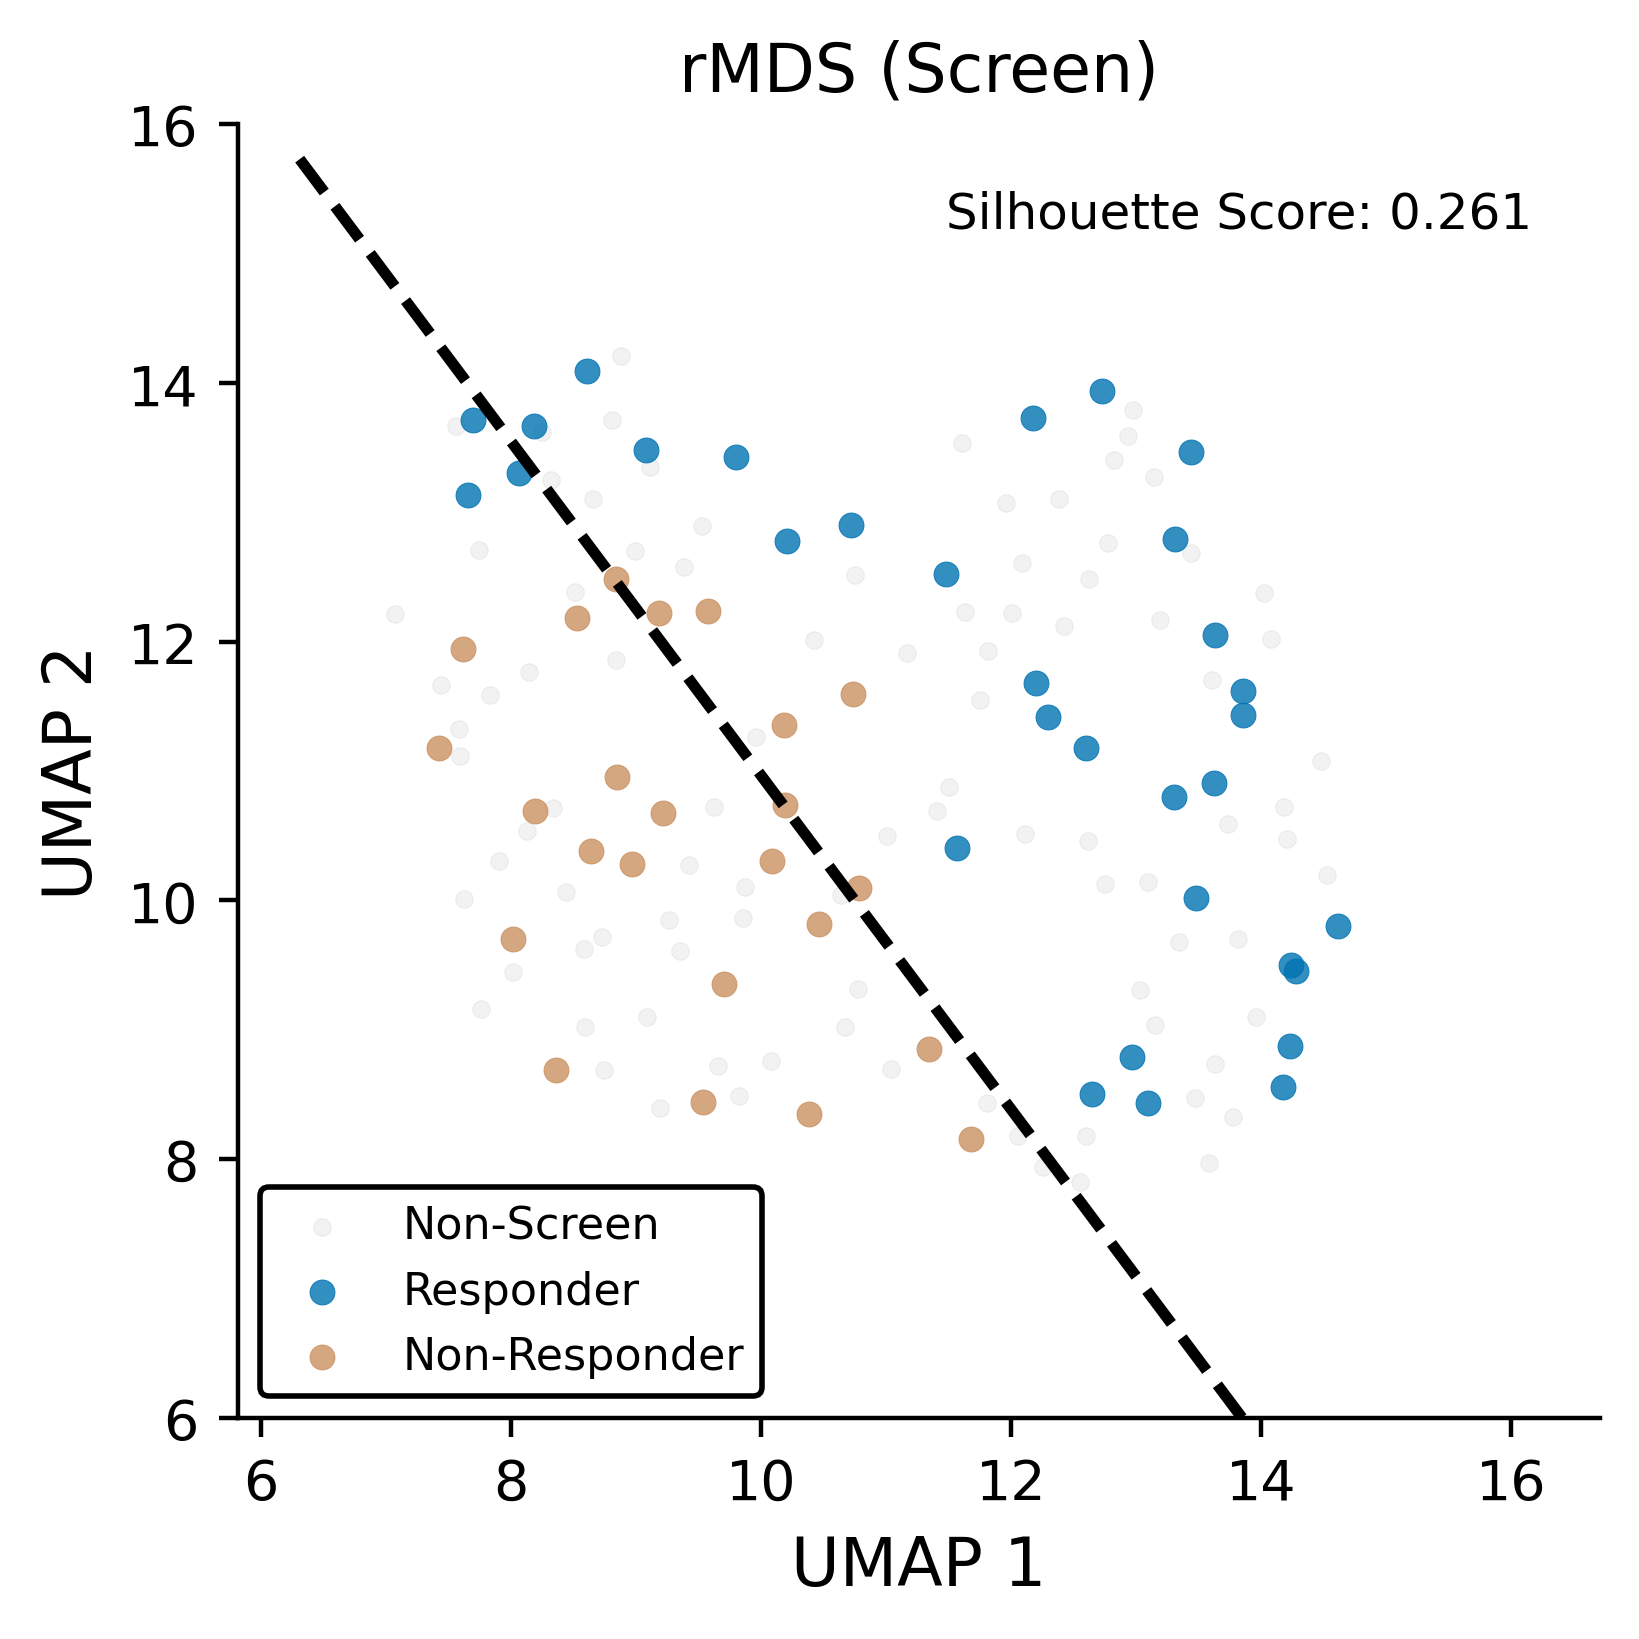

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

visit_metadata = hc_data.get_metadata_col("Type of Visit")
umap_df['Type Of Visit'] = visit_metadata

screen_data = umap_df[umap_df['Type Of Visit'] == 'Screen']
non_screen_data = umap_df[umap_df['Type Of Visit'] != 'Screen']

screen_coords = screen_data[['UMAP1', 'UMAP2']]
score = silhouette_score(screen_coords, screen_data['Treatment Response'])

unique_treatments = screen_data['Treatment Response'].unique()
colors = sns.color_palette('colorblind', 10)
selected_colors = [colors[5], colors[0]]
color_map = {treatment: selected_colors[i % len(selected_colors)] for i, treatment in enumerate(unique_treatments)}

fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=400)

ax.scatter(non_screen_data['UMAP1'], non_screen_data['UMAP2'],
           color="gray", label="Non-Screen", s=10, linewidth=0.2, alpha=0.1)

for treatment, color in reversed(list(color_map.items())):
    subset = screen_data[screen_data['Treatment Response'] == treatment]
    ax.scatter(subset['UMAP1'], subset['UMAP2'], color=color, label=treatment,
               s=20, linewidth=0.2, alpha=0.8)

ax.plot(x_vals, y_vals, linestyle='--', color='black', linewidth=2)

ax.text(0.95, 0.95, f'Silhouette Score: {score:.3f}', 
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_ylim(6, 16)
ax.legend(loc='lower left', fontsize=8, frameon=True, edgecolor='black', facecolor='white', framealpha=1)
sns.despine()

plt.title('rMDS (Screen)')
plt.tight_layout()
plt.savefig("F2C.rMDS.Screen.pdf", dpi=600)
plt.show()

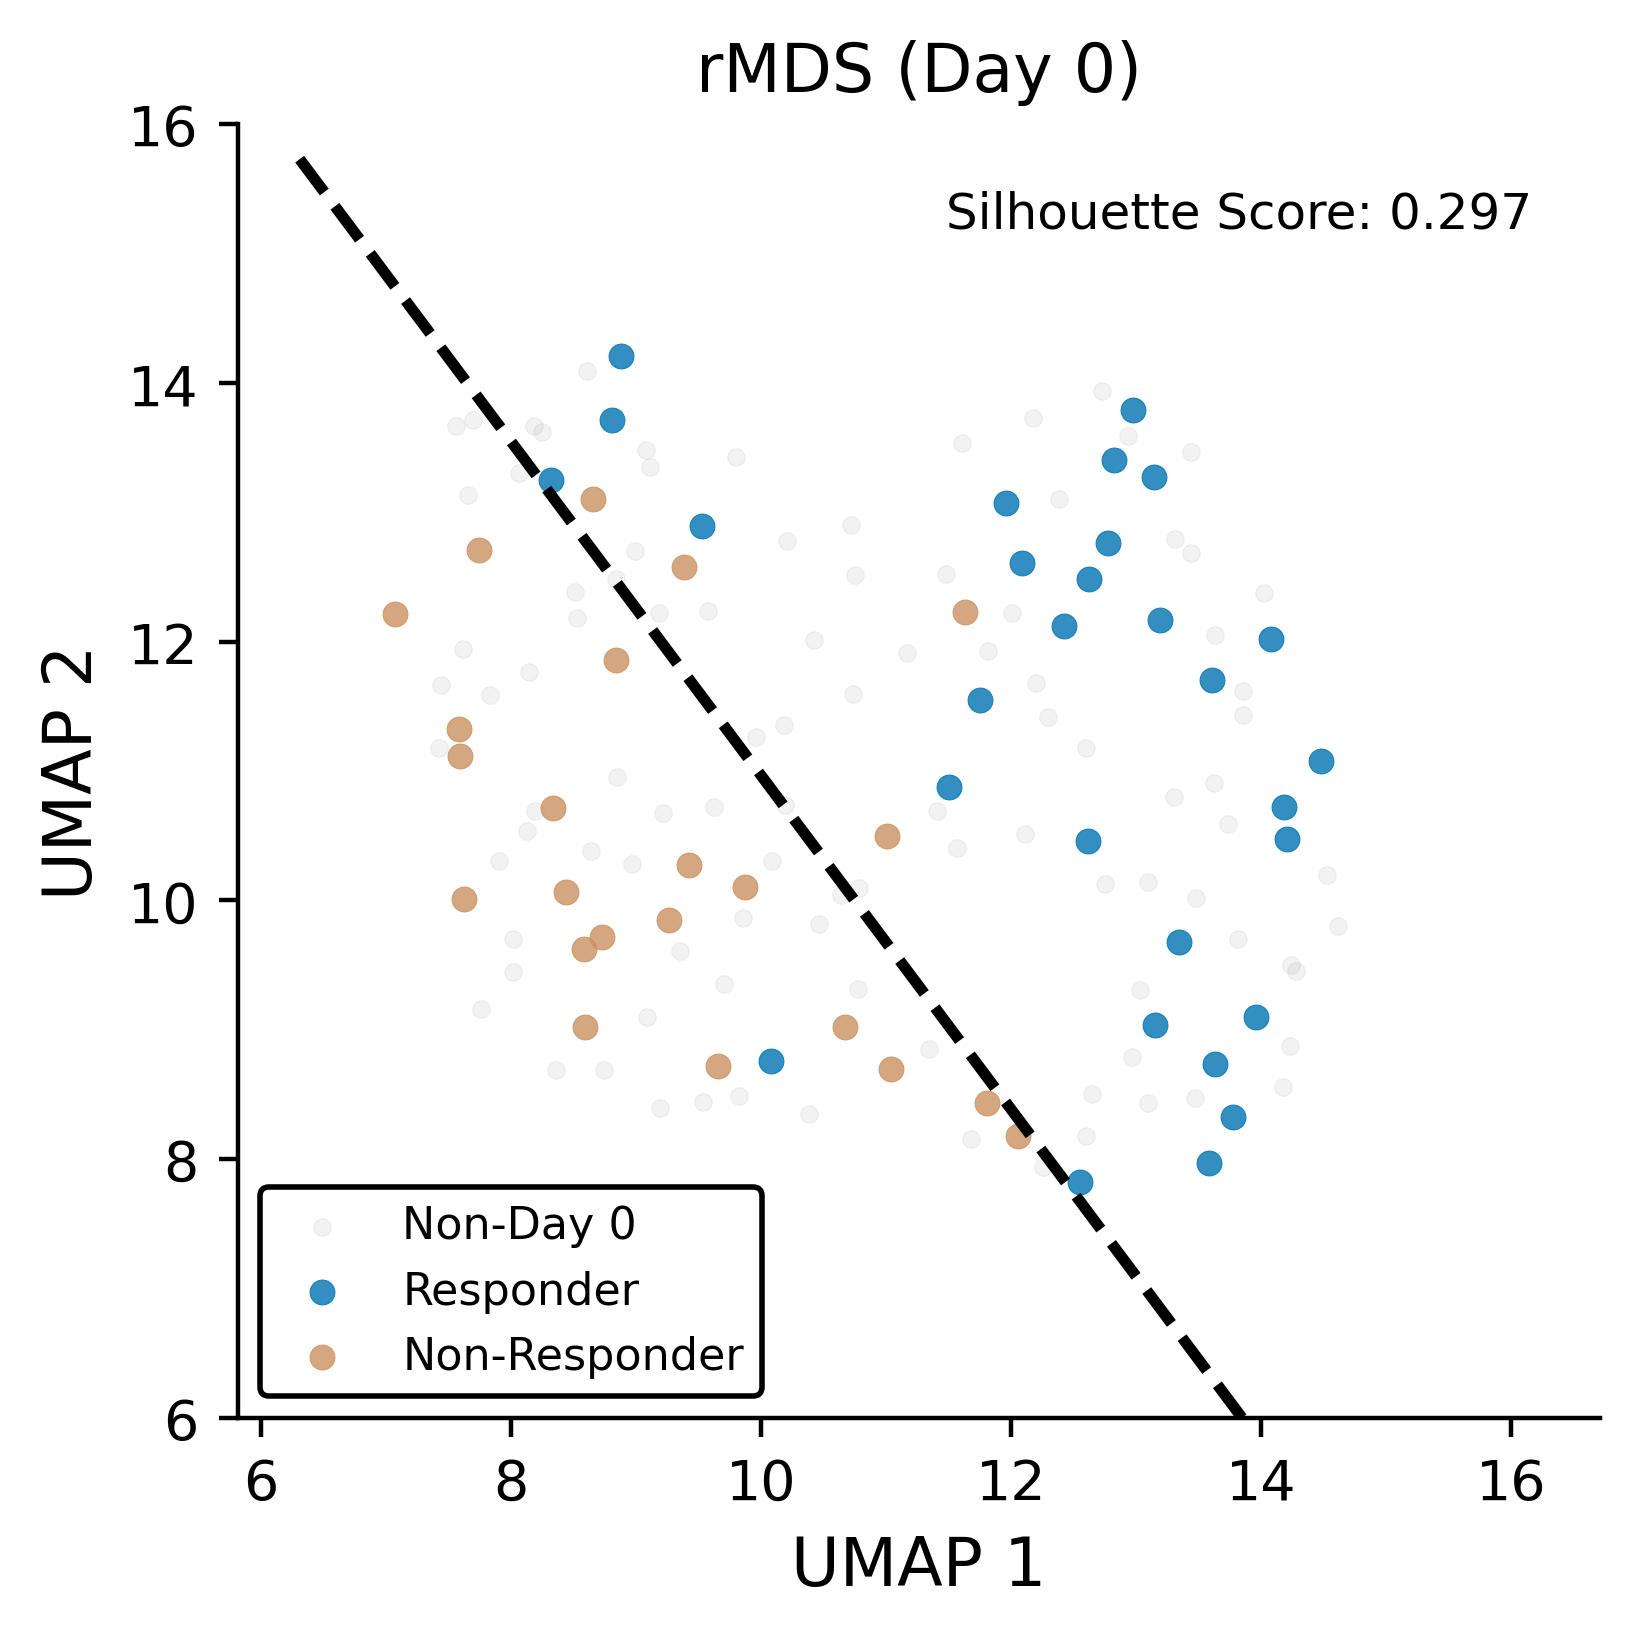

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

visit_metadata = hc_data.get_metadata_col("Type of Visit")
umap_df['Type Of Visit'] = visit_metadata

screen_data = umap_df[umap_df['Type Of Visit'] == 'Day 0']
non_screen_data = umap_df[umap_df['Type Of Visit'] != 'Day 0']

day0_coords = screen_data[['UMAP1', 'UMAP2']]
score = silhouette_score(day0_coords, screen_data['Treatment Response'])

unique_treatments = screen_data['Treatment Response'].unique()
colors = sns.color_palette('colorblind', 10)
selected_colors = [colors[5], colors[0]]
color_map = {treatment: selected_colors[i % len(selected_colors)] for i, treatment in enumerate(unique_treatments)}

fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=400)

ax.scatter(non_screen_data['UMAP1'], non_screen_data['UMAP2'],
           color="gray", label="Non-Day 0", s=10, linewidth=0.2, alpha=0.1)

for treatment, color in reversed(list(color_map.items())):
    subset = screen_data[screen_data['Treatment Response'] == treatment]
    ax.scatter(subset['UMAP1'], subset['UMAP2'], color=color, label=treatment,
               s=20, linewidth=0.2, alpha=0.8)

ax.plot(x_vals, y_vals, linestyle='--', color='black', linewidth=2)

ax.text(0.95, 0.95, f'Silhouette Score: {score:.3f}', 
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_ylim(6, 16)
ax.legend(loc='lower left', fontsize=8, frameon=True, edgecolor='black', facecolor='white', framealpha=1)
sns.despine()

plt.title('rMDS (Day 0)')
plt.tight_layout()
plt.savefig("F2C.rMDS.Day_0.pdf", dpi=600)
plt.show()

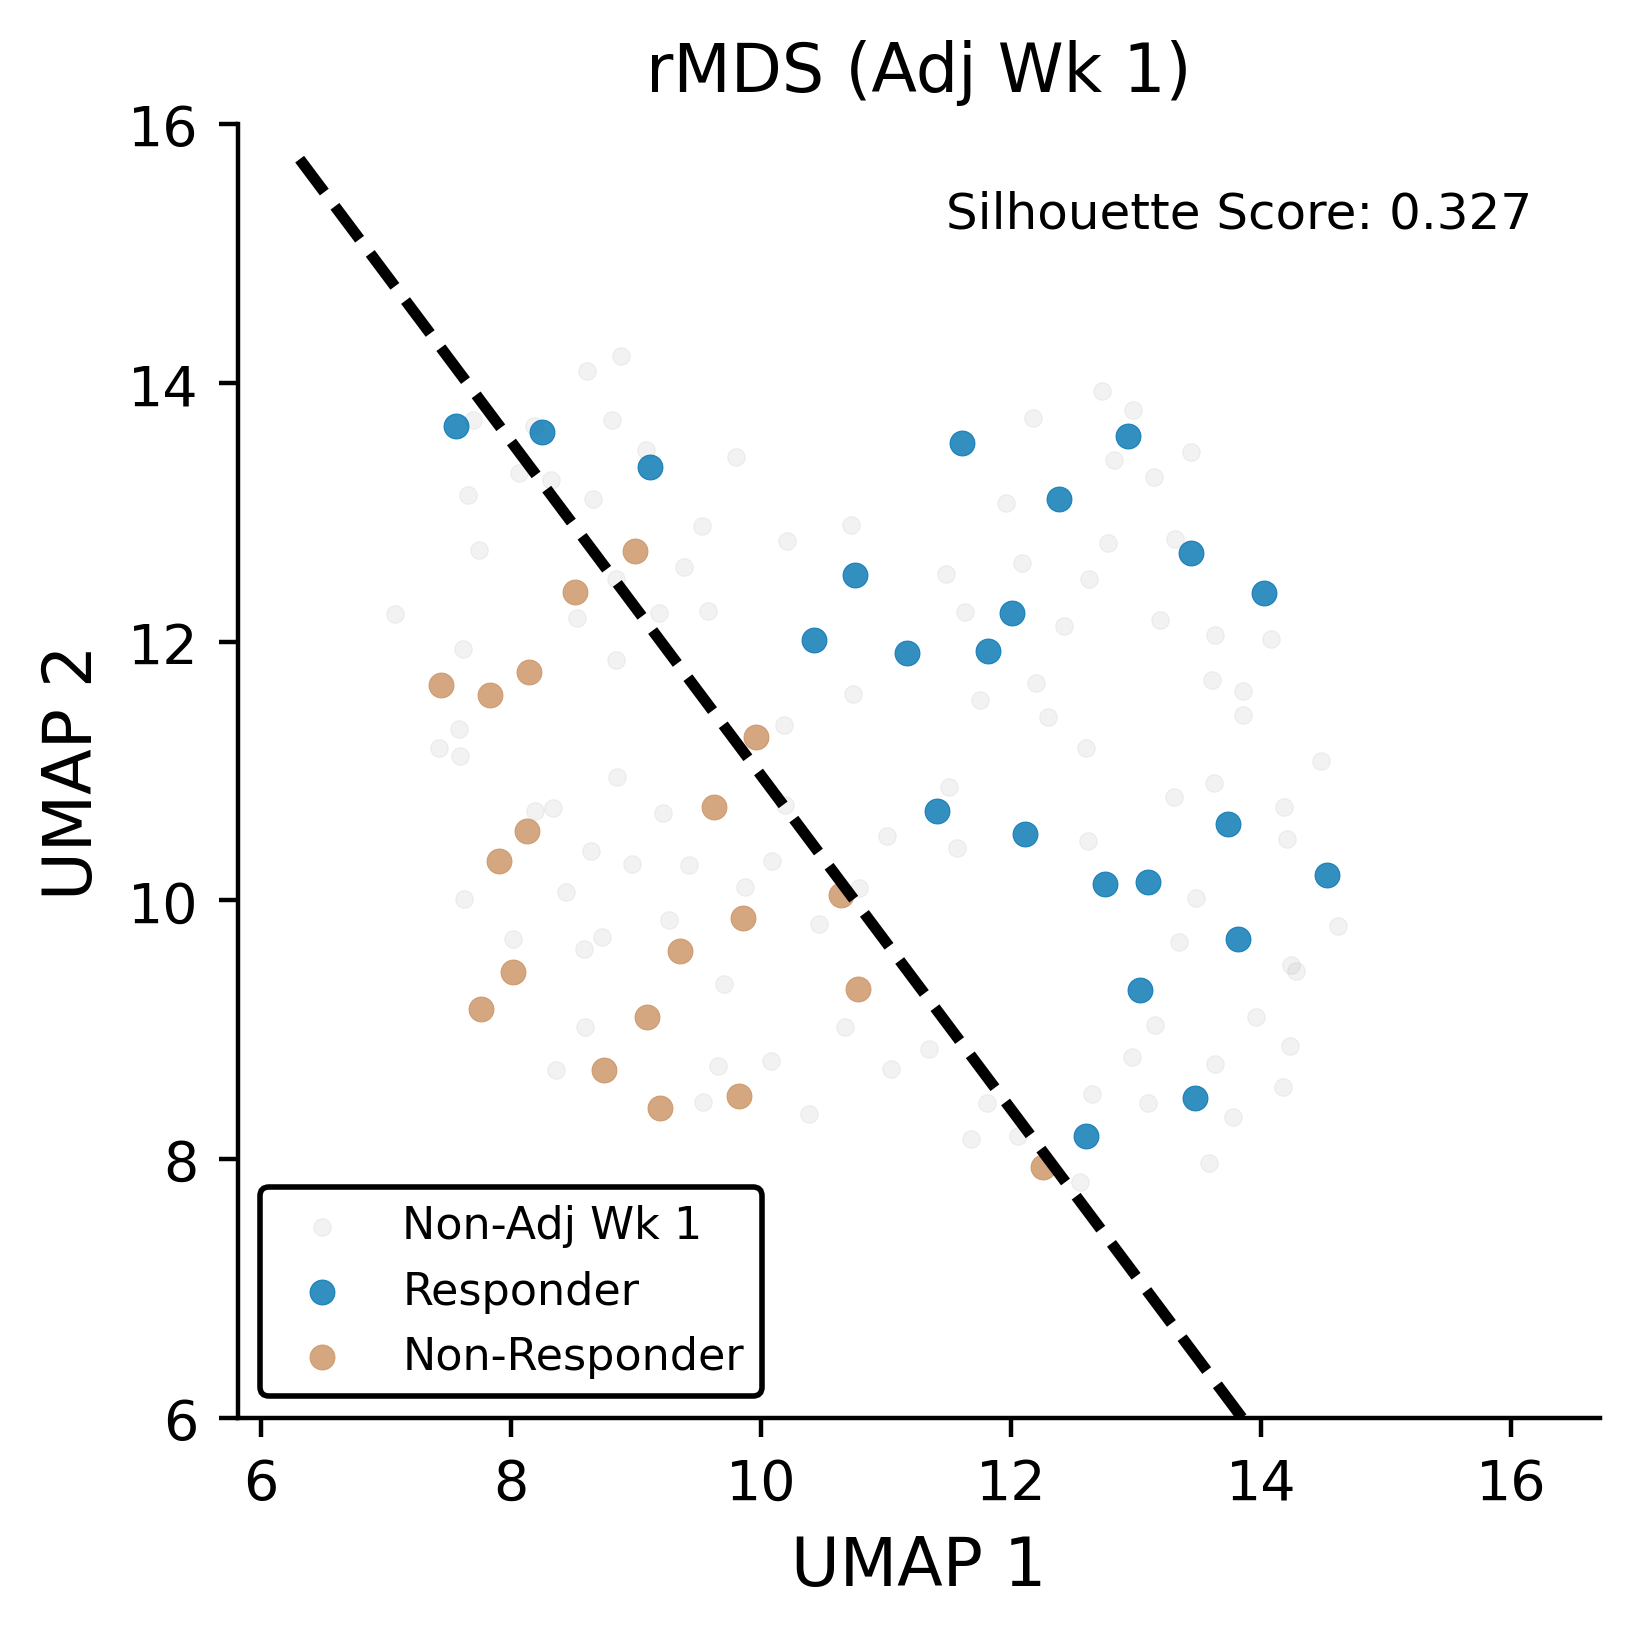

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

visit_metadata = hc_data.get_metadata_col("Type of Visit")
umap_df['Type Of Visit'] = visit_metadata

screen_data = umap_df[umap_df['Type Of Visit'] == 'Adj Wk 1']
non_screen_data = umap_df[umap_df['Type Of Visit'] != 'Adj Wk 1']

adj_wk1_coords = screen_data[['UMAP1', 'UMAP2']]
score = silhouette_score(adj_wk1_coords, screen_data['Treatment Response'])

unique_treatments = screen_data['Treatment Response'].unique()
colors = sns.color_palette('colorblind', 10)
selected_colors = [colors[5], colors[0]]
color_map = {treatment: selected_colors[i % len(selected_colors)] for i, treatment in enumerate(unique_treatments)}

fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=400)

ax.scatter(non_screen_data['UMAP1'], non_screen_data['UMAP2'],
           color="gray", label="Non-Adj Wk 1", s=10, linewidth=0.2, alpha=0.1)

for treatment, color in reversed(list(color_map.items())):
    subset = screen_data[screen_data['Treatment Response'] == treatment]
    ax.scatter(subset['UMAP1'], subset['UMAP2'], color=color, label=treatment,
               s=20, linewidth=0.2, alpha=0.8)

ax.plot(x_vals, y_vals, linestyle='--', color='black', linewidth=2)

ax.text(0.95, 0.95, f'Silhouette Score: {score:.3f}', 
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_ylim(6, 16)
ax.legend(loc='lower left', fontsize=8, frameon=True, edgecolor='black', facecolor='white', framealpha=1)
sns.despine()

plt.title('rMDS (Adj Wk 1)')
plt.tight_layout()
plt.savefig("F2C.rMDS.Adj_Wk_1.pdf", dpi=600)
plt.show()